In [16]:
import pandas as pd

In [17]:
df = pd.read_csv('Crop_recommendation.xls')

In [18]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [19]:
df.shape

(2200, 8)

In [20]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [21]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


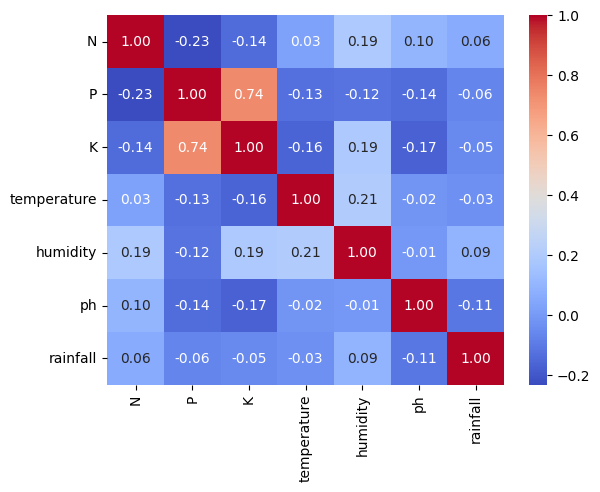

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True),annot=True, fmt='.2f',cmap='coolwarm')
plt.show()

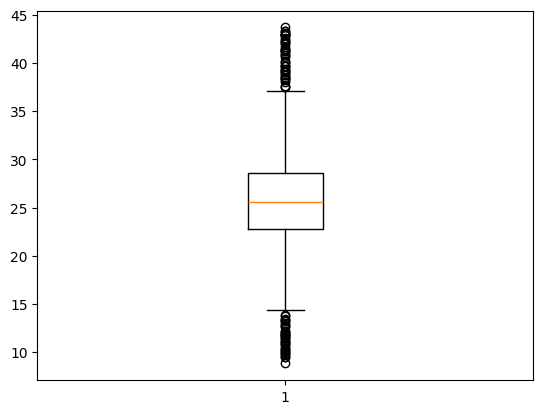

In [36]:
plt.boxplot(df['temperature'])
plt.show()

In [43]:
result = df[df['temperature'] > 40]
print(result)

       N    P    K  temperature   humidity        ph    rainfall   label
1247  39  139  201    41.186649  81.017834  5.539981   68.688959  grapes
1259  17  136  195    41.207336  81.610510  6.389783   65.902275  grapes
1262  32  130  196    40.660123  81.249960  6.372960   74.030301  grapes
1275   8  136  201    41.656030  82.221182  5.609256   74.196648  grapes
1279  38  135  203    41.361063  82.797830  6.444373   69.921075  grapes
1287  29  122  196    41.948657  81.155952  5.638328   73.068630  grapes
1701  58   46   45    42.394134  90.790281  6.576261   88.466075  papaya
1704  31   68   45    42.923253  90.076005  6.938313  196.240824  papaya
1709  69   64   47    40.211993  94.507669  6.993473  186.676232  papaya
1710  58   51   47    42.134740  91.704454  6.757471  197.402901  papaya
1722  61   64   52    43.302049  92.834054  6.641099  110.562229  papaya
1724  31   48   45    40.788818  92.909514  6.563135  132.792359  papaya
1732  50   59   47    40.769987  92.092786  6.74797

In [9]:
X = df.drop('label',axis=1)
y = df['label']

In [10]:
y.value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [13]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)



In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

lr = LogisticRegression()
lr.fit(X_train_scale, y_train)
y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)

print('train')
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, average='weighted'))
print(recall_score(y_train, y_pred_train , average='weighted'))
print(f1_score(y_train, y_pred_train, average='weighted'))

print('test')
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred, average='weighted'))
print(recall_score(y_test, y_pred, average='weighted'))
print(f1_score(y_test, y_pred, average='weighted'))

train
0.9738636363636364
0.9740381606265425
0.9738636363636364
0.973841072273623
test
0.9727272727272728
0.974021729904083
0.9727272727272728
0.9724640256149185


In [44]:
from sklearn.naive_bayes import GaussianNB


naive = GaussianNB()
naive.fit(X_train_scale, y_train)
y_pred = naive.predict(X_test_scale)
y_pred_train = naive.predict(X_train_scale)

print('train')
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, average='weighted'))
print(recall_score(y_train, y_pred_train , average='weighted'))
print(f1_score(y_train, y_pred_train, average='weighted'))

print('test')
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred, average='weighted'))
print(recall_score(y_test, y_pred, average='weighted'))
print(f1_score(y_test, y_pred, average='weighted'))

train
0.9948863636363636
0.994995907276609
0.9948863636363636
0.9948834987551248
test
0.9954545454545455
0.9958677685950413
0.9954545454545455
0.9954431533378901
